# Skalenniveau und Messniveau

> Quelle: [numiqo.de](https://numiqo.de/tutorial/skalenniveau)

Das **Skalenniveau** (auch **Messniveau**) ist eine der wichtigsten Eigenschaften von Variablen in der Statistik. Es bestimmt:
- welche **Rechenoperationen** zulässig sind
- welche **statistischen Tests** angewendet werden können
- welche **Diagramme** sinnvoll sind

> Je höher das Skalenniveau, desto mehr Vergleichsaussagen und Rechenoperationen sind möglich.

Die drei Hauptkategorien sind: **nominal**, **ordinal** und **metrisch**.

## 1. Überblick: Die vier Skalenniveaus

| Skalenniveau | Kategorie | Eigenschaften | Beispiele |
|---|---|---|---|
| **Nominalskala** | Kategorisch | Unterscheiden (=, ≠) | Geschlecht, Familienstand, Zeitung |
| **Ordinalskala** | Kategorisch | Unterscheiden + Reihen (>, <) | Schulnoten, Likert-Skala, Häufigkeit |
| **Intervallskala** | Metrisch | + Abstände interpretierbar | Temperatur in °C, IQ-Score |
| **Verhältnisskala** | Metrisch | + Absoluter Nullpunkt | Gewicht, Alter, Einkommen, Zeit |

In der Praxis werden **Intervall-** und **Verhältnisskala** oft unter dem Begriff metrisch zusammengefasst.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 2. Nominalskala

Die **Nominalskala** ist das **niedrigste Skalenniveau** – sie hat den geringsten Informationsgehalt.

- Ausprägungen können nur **unterschieden** werden (gleich / ungleich)
- **Keine** logische Rangordnung
- Die Reihenfolge der Kategorien ist **austauschbar**
- Bei nur zwei Ausprägungen: **binär** / **dichotom** (z. B. Ja/Nein)

### Beispiele:
- Geschlecht: männlich, weiblich
- Familienstand: ledig, verheiratet, geschieden, verwitwet
- Zeitung: Bild, FAZ, Handelsblatt, …
- Telefonnummern, Wohnorte, Religionsbekenntnis

### Zulässige Statistiken:
- Modus (häufigste Kategorie)
- Häufigkeitstabellen
- Chi-Quadrat-Test

Häufigkeitstabelle – Geschlecht:
männlich    5
weiblich    5
Name: count, dtype: int64

Modus (häufigste Kategorie): männlich


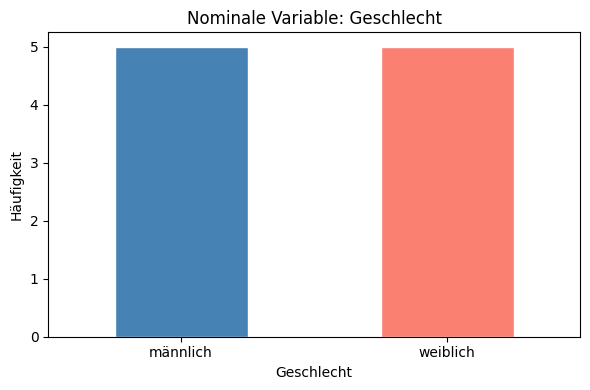

In [2]:
# Beispiel: Nominale Variable – Geschlecht
geschlecht = pd.Series(['männlich', 'weiblich', 'weiblich', 'männlich', 'männlich',
                        'weiblich', 'männlich', 'weiblich', 'weiblich', 'männlich'])

haeufigkeit = geschlecht.value_counts()
print("Häufigkeitstabelle – Geschlecht:")
print(haeufigkeit)
print(f"\nModus (häufigste Kategorie): {geschlecht.mode()[0]}")

# Balkendiagramm
fig, ax = plt.subplots(figsize=(6, 4))
haeufigkeit.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('Nominale Variable: Geschlecht')
ax.set_xlabel('Geschlecht')
ax.set_ylabel('Häufigkeit')
ax.set_xticklabels(haeufigkeit.index, rotation=0)
plt.tight_layout()
plt.show()

## 3. Ordinalskala

Die **Ordinalskala** ist das nächsthöhere Skalenniveau (auch: **Rangskala**).

- Enthält alle Eigenschaften der Nominalskala
- Zusätzlich: **Rangfolge** ist möglich (>, <)
- **Aber:** Die Abstände zwischen den Ausprägungen sind **nicht interpretierbar**

> Beispiel Schulnoten: Eine 1 ist besser als eine 2, aber der Abstand zwischen 1 und 2 ist **nicht notwendigerweise gleich** dem Abstand zwischen 3 und 4.

### Beispiele:
- Schulnoten (1–5)
- Häufigkeit des Fernsehens: täglich > mehrmals/Woche > seltener > nie
- Likert-Skala: stimme zu / unentschieden / lehne ab
- Produktbewertung (1–5 Sterne)

### Zulässige Statistiken:
- Modus, Median
- Häufigkeitstabellen, Rangkorrelation (Spearman)
- Mann-Whitney-U-Test, Wilcoxon-Test

Häufigkeitstabelle – Schulnoten:
1    4
2    5
3    3
4    2
5    1
Name: count, dtype: int64

Median: 2.0
Modus:  2

Hinweis: Mittelwert bei Ordinalskala nur mit Vorsicht interpretieren!
Mittelwert (zur Illustration): 2.40


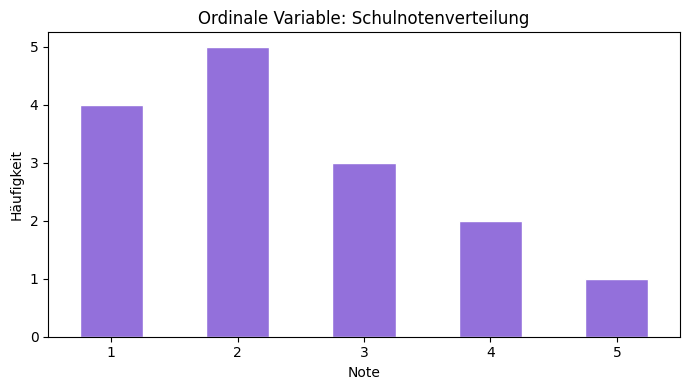

In [3]:
# Beispiel: Ordinale Variable – Schulnoten
noten = pd.Series([2, 1, 3, 2, 4, 1, 2, 3, 2, 1, 3, 5, 2, 1, 4])

print("Häufigkeitstabelle – Schulnoten:")
haeuf_noten = noten.value_counts().sort_index()
print(haeuf_noten)
print(f"\nMedian: {noten.median()}")
print(f"Modus:  {noten.mode()[0]}")
print("\nHinweis: Mittelwert bei Ordinalskala nur mit Vorsicht interpretieren!")
print(f"Mittelwert (zur Illustration): {noten.mean():.2f}")

# Balkendiagramm
fig, ax = plt.subplots(figsize=(7, 4))
haeuf_noten.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Ordinale Variable: Schulnotenverteilung')
ax.set_xlabel('Note')
ax.set_ylabel('Häufigkeit')
ax.set_xticklabels(haeuf_noten.index, rotation=0)
plt.tight_layout()
plt.show()

## 4. Kategorische Variablen (Oberbegriff)

Variablen mit **Nominalskala** oder **Ordinalskala** werden gemeinsam als **kategorische Variablen** bezeichnet.

- Sie haben eine **begrenzte, fixe Anzahl** von Ausprägungen
- Beispiele: Geschlecht (2 Kategorien), Land (viele Kategorien)
- Die Kategorien können eine Rangfolge haben (ordinal), müssen es aber nicht (nominal)

```
Kategorisch
├── Nominal  (keine Rangordnung)
└── Ordinal  (mit Rangordnung, aber ohne interpretierbaren Abstand)
```

## 5. Metrische Variablen

Metrische Variablen haben das **höchste Skalenniveau**.

- Ausprägungen können verglichen und sortiert werden
- **Abstände** zwischen den Ausprägungen können berechnet werden
- Differenzen und Summen sind sinnvoll

### Beispiele:
- Einkommen in €
- Gewicht in kg
- Alter in Jahren
- Stromverbrauch in kWh

### Zulässige Statistiken:
- Modus, Median, **Mittelwert**
- **Standardabweichung**, Varianz
- t-Test, ANOVA, Korrelation, Regression

### Untergliederung: Intervall- vs. Verhältnisskala

| | Intervallskala | Verhältnisskala |
|---|---|---|
| Abstände interpretierbar | ✅ | ✅ |
| Absoluter Nullpunkt | ❌ | ✅ |
| Verhältnisse bildbar | ❌ | ✅ |
| Beispiel | Temperatur in °C, IQ | Gewicht, Alter, Zeit |

> **Verhältnisskala:** "Läufer A ist doppelt so schnell wie Läufer B" – möglich, weil es einen absoluten Nullpunkt gibt.  
> **Intervallskala:** Bei Celsius kann nicht gesagt werden, 20°C ist "doppelt so warm" wie 10°C – kein absoluter Nullpunkt.

Deskriptive Statistiken: Einkommen (metrisch)
Mittelwert:         2807.22 €
Median:             2760.50 €
Standardabweichung: 614.36 €
Min:                1427.00 €
Max:                4156.00 €


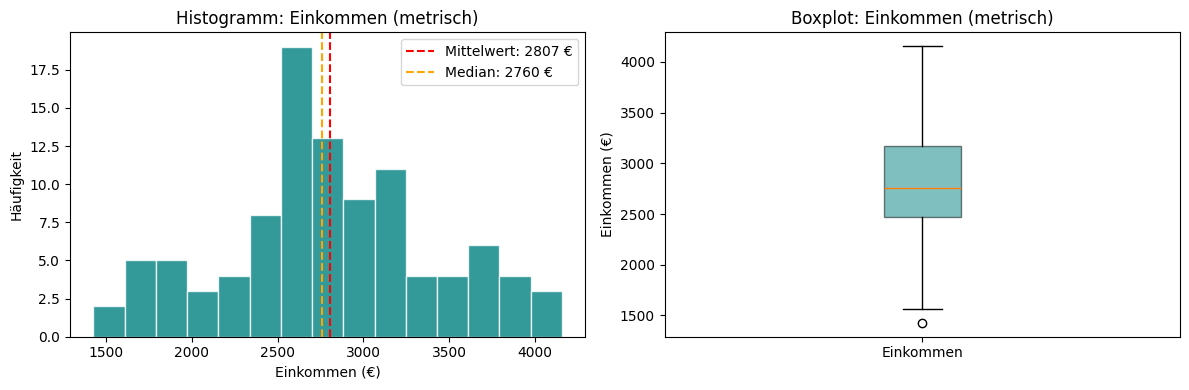

In [8]:
# Beispiel: Metrische Variable – Einkommen
np.random.seed(7)
einkommen = pd.Series(np.random.normal(loc=2800, scale=600, size=100).round(0))

print("Deskriptive Statistiken: Einkommen (metrisch)")
print(f"Mittelwert:         {einkommen.mean():.2f} €")
print(f"Median:             {einkommen.median():.2f} €")
print(f"Standardabweichung: {einkommen.std():.2f} €")
print(f"Min:                {einkommen.min():.2f} €")
print(f"Max:                {einkommen.max():.2f} €")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramm
axes[0].hist(einkommen, bins=15, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(einkommen.mean(), color='red', linestyle='--', label=f'Mittelwert: {einkommen.mean():.0f} €')
axes[0].axvline(einkommen.median(), color='orange', linestyle='--', label=f'Median: {einkommen.median():.0f} €')
axes[0].set_title('Histogramm: Einkommen (metrisch)')
axes[0].set_xlabel('Einkommen (€)')
axes[0].set_ylabel('Häufigkeit')
axes[0].legend()

# Boxplot
axes[1].boxplot(einkommen, patch_artist=True, boxprops=dict(facecolor='teal', alpha=0.5))
axes[1].set_title('Boxplot: Einkommen (metrisch)')
axes[1].set_ylabel('Einkommen (€)')
axes[1].set_xticklabels(['Einkommen'])

plt.tight_layout()
plt.show()

## 6. Skalenniveau – Beispieltabelle

Die folgende Tabelle zeigt typische Variablen und ihre Skalenniveaus:

In [5]:
beispiele = pd.DataFrame({
    'Nr.': range(1, 11),
    'Variable': [
        'Wohnorte in Deutschland',
        'Produktbewertung (1–5 Sterne)',
        'Religionsbekenntnis',
        'CO₂-Ausstoß im Jahr',
        'IQ-Score von SchülerInnen',
        'Prüfungsnoten (1–5)',
        'Telefonnummern',
        'Pflegestufe eines Patienten',
        'Wohnfläche in m²',
        'Arbeitszufriedenheit (1–4)'
    ],
    'Skalenniveau': [
        'Nominal',
        'Ordinal',
        'Nominal',
        'Metrisch (Verhältnis)',
        'Metrisch (Intervall)',
        'Ordinal',
        'Nominal',
        'Ordinal',
        'Metrisch (Verhältnis)',
        'Ordinal'
    ]
})

print(beispiele.to_string(index=False))

 Nr.                      Variable          Skalenniveau
   1       Wohnorte in Deutschland               Nominal
   2 Produktbewertung (1–5 Sterne)               Ordinal
   3           Religionsbekenntnis               Nominal
   4           CO₂-Ausstoß im Jahr Metrisch (Verhältnis)
   5     IQ-Score von SchülerInnen  Metrisch (Intervall)
   6           Prüfungsnoten (1–5)               Ordinal
   7                Telefonnummern               Nominal
   8   Pflegestufe eines Patienten               Ordinal
   9              Wohnfläche in m² Metrisch (Verhältnis)
  10    Arbeitszufriedenheit (1–4)               Ordinal


## 7. Welche Statistiken sind je Skalenniveau erlaubt?

Das Skalenniveau bestimmt, welche Kennzahlen und Tests sinnvoll sind:

In [6]:
# Übersichtstabelle: Zulässige Operationen je Skalenniveau
operationen = pd.DataFrame({
    'Operation / Kennzahl': [
        'Gleich / Ungleich (= / ≠)',
        'Größer / Kleiner (> / <)',
        'Abstände berechnen',
        'Verhältnisse bilden',
        'Modus',
        'Median',
        'Mittelwert',
        'Standardabweichung / Varianz',
        'Chi-Quadrat-Test',
        'Mann-Whitney / Wilcoxon',
        't-Test / ANOVA',
        'Pearson-Korrelation / Regression'
    ],
    'Nominal': ['✅','❌','❌','❌','✅','❌','❌','❌','✅','❌','❌','❌'],
    'Ordinal': ['✅','✅','❌','❌','✅','✅','⚠️','❌','✅','✅','❌','❌'],
    'Metrisch': ['✅','✅','✅','✅','✅','✅','✅','✅','✅','✅','✅','✅']
})

print(operationen.to_string(index=False))
print("\n⚠️ = nur mit Vorsicht und korrekter Interpretation")

            Operation / Kennzahl Nominal Ordinal Metrisch
       Gleich / Ungleich (= / ≠)       ✅       ✅        ✅
        Größer / Kleiner (> / <)       ❌       ✅        ✅
              Abstände berechnen       ❌       ❌        ✅
             Verhältnisse bilden       ❌       ❌        ✅
                           Modus       ✅       ✅        ✅
                          Median       ❌       ✅        ✅
                      Mittelwert       ❌      ⚠️        ✅
    Standardabweichung / Varianz       ❌       ❌        ✅
                Chi-Quadrat-Test       ✅       ✅        ✅
         Mann-Whitney / Wilcoxon       ❌       ✅        ✅
                  t-Test / ANOVA       ❌       ❌        ✅
Pearson-Korrelation / Regression       ❌       ❌        ✅

⚠️ = nur mit Vorsicht und korrekter Interpretation


## 8. Visualisierung: Skalenniveaus im Vergleich

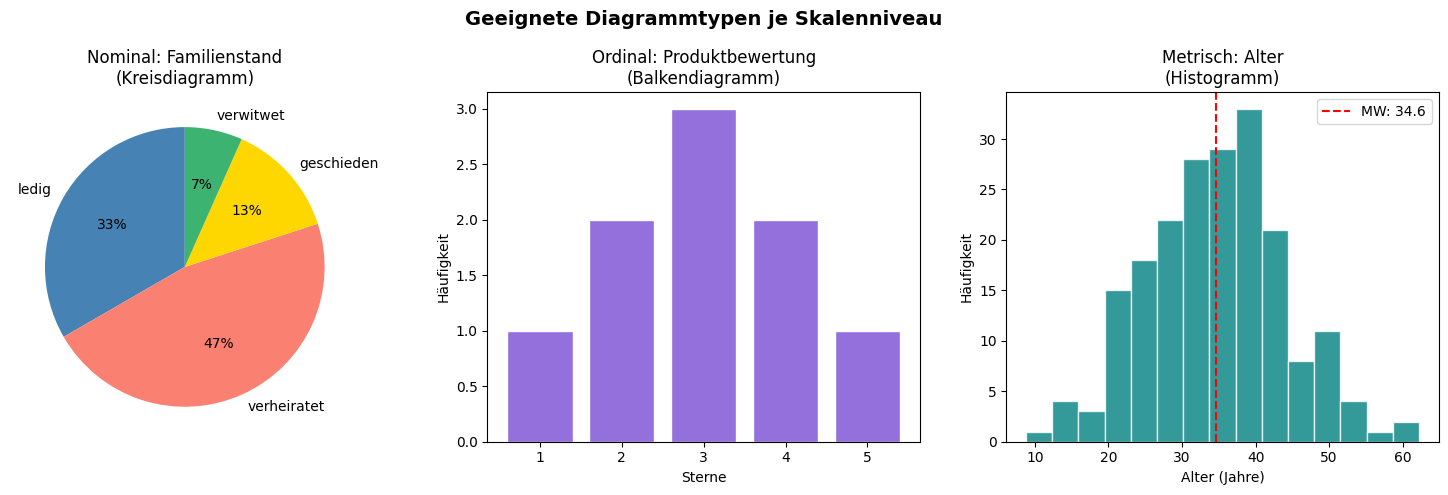

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Geeignete Diagrammtypen je Skalenniveau', fontsize=14, fontweight='bold')

# 1. Nominal → Kreisdiagramm
familienstand = {'ledig': 5, 'verheiratet': 7, 'geschieden': 2, 'verwitwet': 1}
axes[0].pie(familienstand.values(), labels=familienstand.keys(),
            autopct='%1.0f%%', colors=['steelblue','salmon','gold','mediumseagreen'],
            startangle=90)
axes[0].set_title('Nominal: Familienstand\n(Kreisdiagramm)')

# 2. Ordinal → Balkendiagramm
bewertungen = pd.Series([1, 2, 2, 3, 3, 3, 4, 4, 5]).value_counts().sort_index()
axes[1].bar(bewertungen.index, bewertungen.values,
            color='mediumpurple', edgecolor='white')
axes[1].set_title('Ordinal: Produktbewertung\n(Balkendiagramm)')
axes[1].set_xlabel('Sterne')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_xticks([1, 2, 3, 4, 5])

# 3. Metrisch → Histogramm
np.random.seed(42)
alter = np.random.normal(35, 10, 200)
axes[2].hist(alter, bins=15, color='teal', edgecolor='white', alpha=0.8)
axes[2].axvline(np.mean(alter), color='red', linestyle='--',
                label=f'MW: {np.mean(alter):.1f}')
axes[2].set_title('Metrisch: Alter\n(Histogramm)')
axes[2].set_xlabel('Alter (Jahre)')
axes[2].set_ylabel('Häufigkeit')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Zusammenfassung

```
Skalenniveaus (von niedrig nach hoch)
│
├── NOMINAL   → nur unterscheiden (=, ≠)
│              Bsp: Geschlecht, Wohnort, Religionsbekenntnis
│
├── ORDINAL   → unterscheiden + sortieren (>, <)
│              Bsp: Schulnoten, Likert-Skala, Pflegestufe
│
└── METRISCH  → unterscheiden + sortieren + Abstände berechnen
    │
    ├── INTERVALL  → kein absoluter Nullpunkt
    │               Bsp: Temperatur (°C), IQ
    │
    └── VERHÄLTNIS → mit absolutem Nullpunkt
                    Bsp: Gewicht, Alter, Einkommen, Zeit
```

---

> **Tipp:** Die Bestimmung des Skalenniveaus ist immer der **erste Schritt** bei der Datenanalyse. Erst wenn das Skalenniveau bekannt ist, kann entschieden werden, welche statistischen Methoden sinnvoll eingesetzt werden können.

Quelle: [numiqo.de/tutorial/skalenniveau](https://numiqo.de/tutorial/skalenniveau)